# TS3: Simulación de un ADC (cuantización) parte 1/2
- Se va a analizar una senoidal ruidosa (SNR=35dB) de potencia unitaria.
- El rango de tensión del ADC es de 4V y se prueba para distintos valores de B.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
  tt = np.arange(start = 0, stop = nn/fs, step = 1/fs)
  xx = dc + vmax * np.sin( 2*np.pi * ff * tt + ph )
  return tt, xx

def mi_cuantizacion(xd, VFS, B):
  q = VFS/(2**(B))
  xq = np.round(xd/q)*q
  xq = np.clip(a=xq, a_min=-VFS/2, a_max=VFS/2)
  return xq

def autocorr(x):
  acorr = np.correlate(x, x, mode='full')
  return acorr[acorr.size//2:]  # desde 0 a +inf

def mi_funcion_sen_con_ruido(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000, snr_db=10):
  # Señal
  tt, xx_s = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=nn, fs=fs)
  Ps = np.mean(xx_s**2)

  # Ruido
  snr_linear = 10**(snr_db / 10)
  Pn = Ps / snr_linear  # Potencia de ruido resultante
  xx_n = np.random.normal(0, np.sqrt(Pn), len(tt))

  xx = xx_s + xx_n

  return tt, xx, xx_s, xx_n

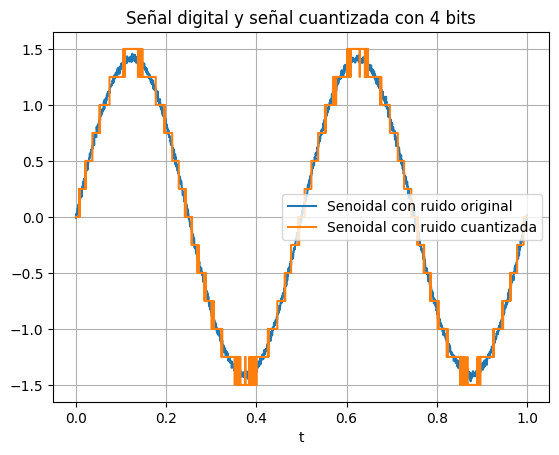

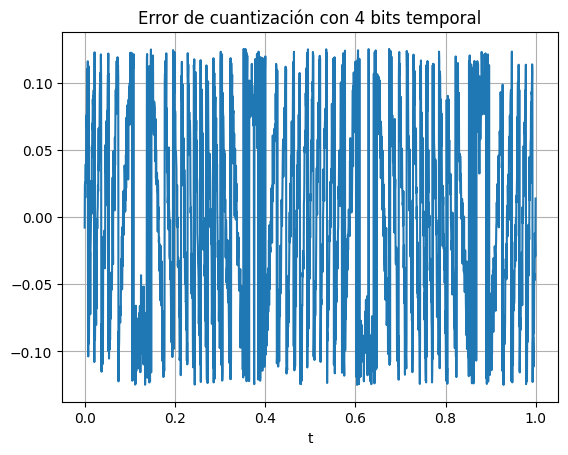

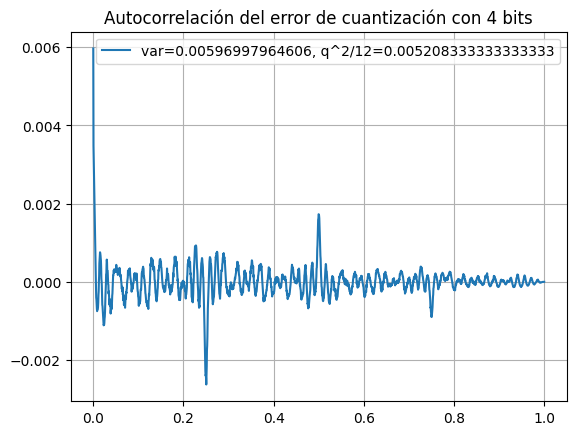

q^2/12 = 0.005208333333333333
Var = 0.00596997964606
eq_autocorr[0] = 0.005970304441125162


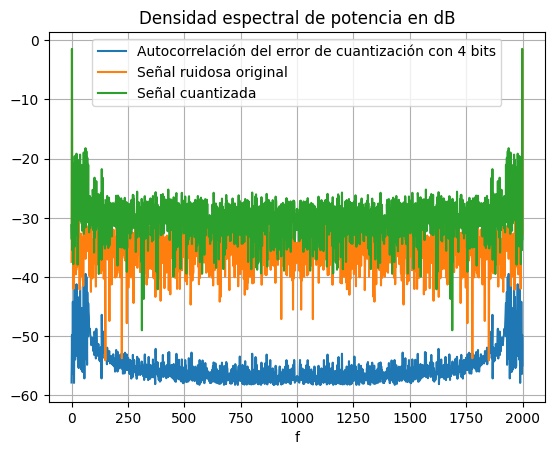

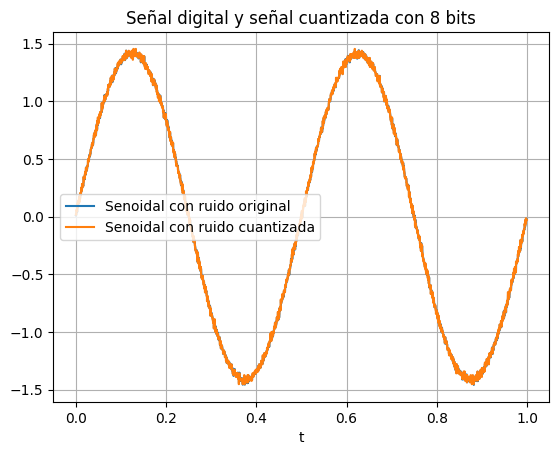

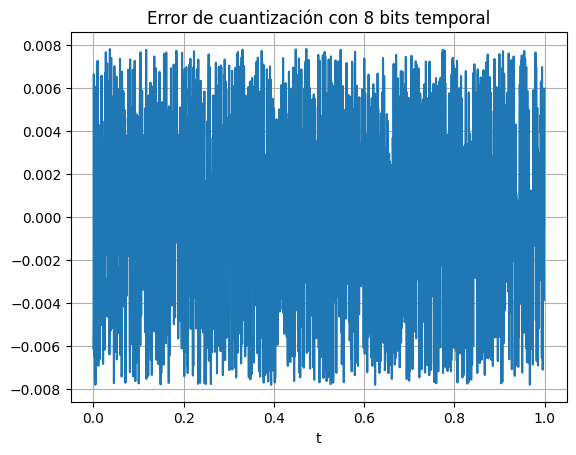

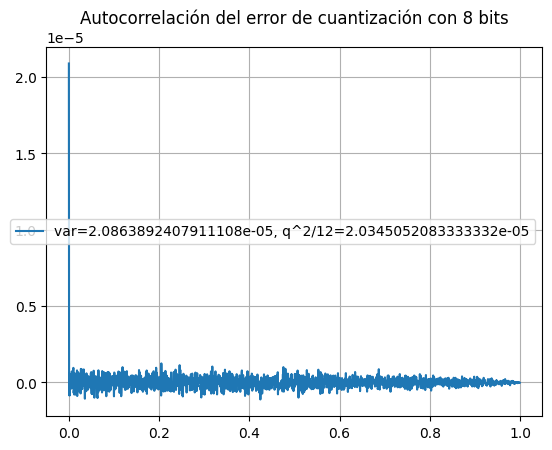

q^2/12 = 2.0345052083333332e-05
Var = 2.0863892407911108e-05
eq_autocorr[0] = 2.087141314575873e-05


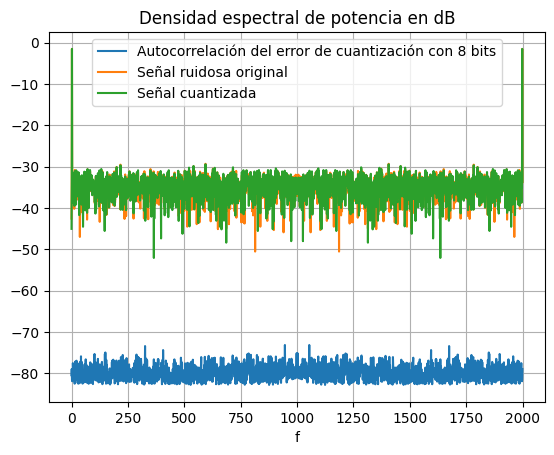

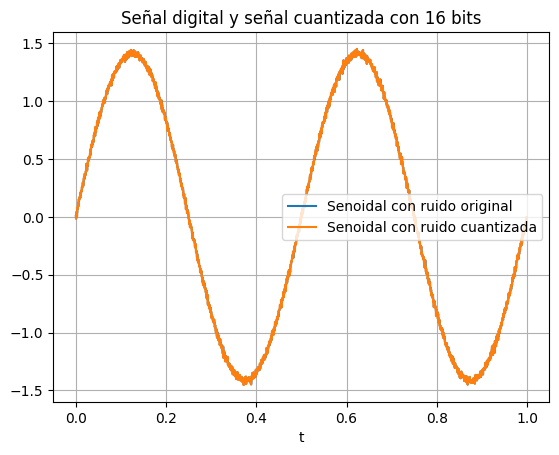

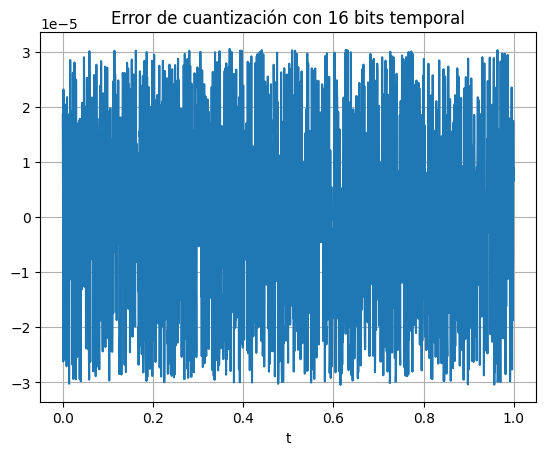

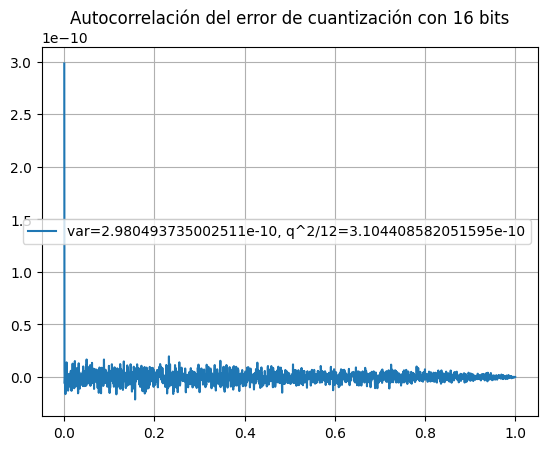

q^2/12 = 3.104408582051595e-10
Var = 2.980493735002511e-10
eq_autocorr[0] = 2.9816966921142064e-10


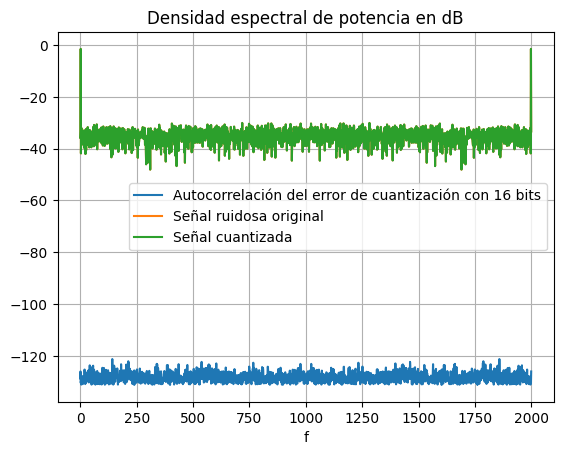

In [4]:
# == Ejemplo de uso ===
fs = 2000 # Hz
N = fs  # Resolución espectral fs/N = 1Hz, tiempo de simulación 1seg

# Parámetros de la señal
f0 = 2*fs/N  # Hz
vp = np.sqrt(2)
snr_db = 35

# Parámetros de cuantización
B_list = [4, 8, 16]  # Valores de B
VF = 2
VFS = 2*VF

for B in B_list:
  #t, x = mi_funcion_sen(vmax=vp, ff=f0, nn=N, fs=fs)
  t, x, x_s, x_n = mi_funcion_sen_con_ruido(vmax=vp, ff=f0, nn=N, fs=fs, snr_db=snr_db)
  xq = mi_cuantizacion(x, VFS, B)

  # Cuantización
  plt.figure()
  plt.title(f"Señal digital y señal cuantizada con {B} bits")
  plt.plot(t, x, label="Senoidal con ruido original")
  plt.step(t, xq, label=f"Senoidal con ruido cuantizada")
  plt.xlabel("t")
  plt.legend()
  plt.grid()
  plt.show()

  eq = x-xq
  plt.figure()
  plt.title(f"Error de cuantización con {B} bits temporal")
  plt.plot(t, eq)
  plt.xlabel("t")
  plt.grid()
  plt.show()

  q = VFS/(2**(B))
  eqvar = np.var(eq, axis=0)
  eq_autocorr = autocorr(eq)/N
  plt.figure()
  plt.title(f"Autocorrelación del error de cuantización con {B} bits")
  plt.plot(t, eq_autocorr, label=f"var={eqvar}, q^2/12={(q**2)/12}")
  plt.legend()
  plt.grid()
  plt.show()
  print(f"q^2/12 = {(q**2)/12}")
  print(f"Var = {eqvar}")
  print(f"eq_autocorr[0] = {eq_autocorr[0]}")

  eq_autocorr_f = np.fft.fft(eq_autocorr, axis=0)/N
  x_f = np.fft.fft(x, axis=0)/N
  xq_f = np.fft.fft(xq, axis=0)/N
  plt.figure()
  plt.title(f"Densidad espectral de potencia en dB")
  plt.plot(10*np.log10(np.abs(eq_autocorr_f)), label=f"Autocorrelación del error de cuantización con {B} bits")
  plt.plot(10*np.log10(np.abs(x_f)), label=f"Señal ruidosa original")
  plt.plot(10*np.log10(np.abs(xq_f)), label=f"Señal cuantizada")
  plt.xlabel("f")
  plt.legend()
  plt.grid()
  plt.show()


## Conclusiones
- La señal cuantizada en el tiempo se ve escalonada, y mientras más bits se usen para cuantizar, más parecida a la señal original se va a ver.
- A la señal se le añadió ruido gaussiano con una SNR de 35 dB, lo que genera que sea una señal no determinística.
- La varianza de eq es aproximadamente q^2/12.
- Al calcular la autocorrelación de eq, esta es similar a una delta en el origen de valor igual a la varianza, lo que indica que el error de cuantización es incorrelado.
- La SNR de la señal a la entrada es menor que la del error de cuantización, así que a la salida la SNR se rige por el ruido analógico.
